# Emotion Detection with Intensity & Progression
## Hackathon Final Notebook

This notebook performs:
- Emotion Detection from text
- Emotion Intensity estimation
- Emotion progression (Start / Middle / End)
- Intensity bar visualization
- Disclaimer generation


## 1. Import Required Libraries

In [6]:

import zipfile
import os
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


## 2. Download NLTK Resources (Run Once)

In [7]:

nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MohanaPrasath\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\MohanaPrasath\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## 3. Extract Dataset ZIP

In [8]:

zip_path = r"C:\Users\MohanaPrasath\Downloads\archive.zip"
extract_path = r"C:\Users\MohanaPrasath\Downloads\emotion_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

os.listdir(extract_path)


['test.txt', 'train.txt', 'val.txt']

## 4. Load Emotion Dataset (.txt format)

In [9]:

def load_emotion_file(file_path):
    texts, emotions = [], []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            text, emotion = line.strip().split(';')
            texts.append(text)
            emotions.append(emotion)
    return pd.DataFrame({'text': texts, 'emotion': emotions})

train_df = load_emotion_file(os.path.join(extract_path, "train.txt"))
test_df  = load_emotion_file(os.path.join(extract_path, "test.txt"))
val_df   = load_emotion_file(os.path.join(extract_path, "val.txt"))
train_df.head()


,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


## 5. Combine Train + Validation Data

In [10]:

df = pd.concat([train_df, val_df], ignore_index=True)
df['emotion'].value_counts()


emotion
joy         6066
sadness     5216
anger       2434
fear        2149
love        1482
surprise     653
Name: count, dtype: int64

## 6. Text Preprocessing

In [11]:

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)


## 7. TF-IDF Vectorization

In [12]:

vectorizer = TfidfVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(df['clean_text'])
X_test  = vectorizer.transform(test_df['clean_text'])

y_train = df['emotion']
y_test  = test_df['emotion']


## 8. Train Logistic Regression Model

In [13]:

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## 9. Model Evaluation

In [14]:

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.8775

Classification Report:

              precision    recall  f1-score   support

       anger       0.88      0.85      0.86       275
        fear       0.88      0.80      0.84       224
         joy       0.86      0.96      0.91       695
        love       0.83      0.65      0.73       159
     sadness       0.91      0.93      0.92       581
    surprise       0.92      0.53      0.67        66

    accuracy                           0.88      2000
   macro avg       0.88      0.79      0.82      2000
weighted avg       0.88      0.88      0.87      2000



## 10. Confusion Matrix

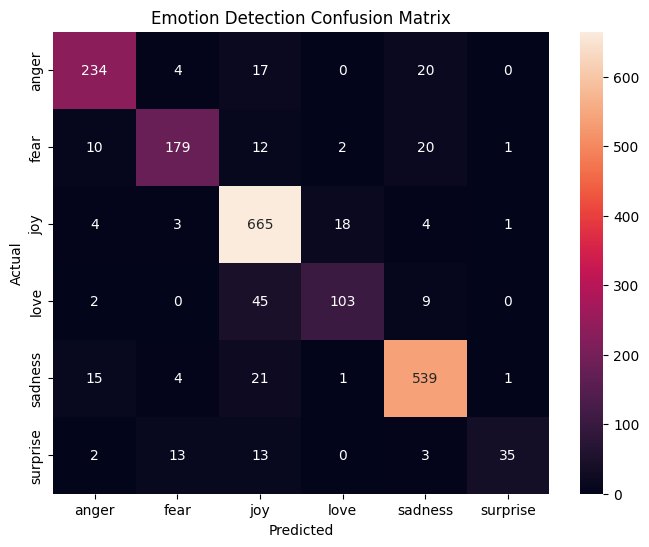

In [15]:

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Emotion Detection Confusion Matrix")
plt.show()


## 11. Emotion Prediction Helper

In [16]:

def predict_emotion(text):
    cleaned = clean_text(text)
    vector = vectorizer.transform([cleaned])
    emotion = model.predict(vector)[0]
    confidence = model.predict_proba(vector).max()
    return emotion, confidence


## 12. Emotion Progression (Start / Middle / End)

In [17]:

def split_text_segments(text):
    words = text.split()
    n = len(words)
    if n < 6:
        return text, text, text
    return (
        " ".join(words[: n//3]),
        " ".join(words[n//3 : 2*n//3]),
        " ".join(words[2*n//3 :])
    )


## 13. Full Emotion Analysis

In [18]:

def emotion_analysis_report(text):
    s, m, e = split_text_segments(text)

    start_em, start_conf = predict_emotion(s)
    mid_em, mid_conf = predict_emotion(m)
    end_em, end_conf = predict_emotion(e)
    overall_em, overall_conf = predict_emotion(text)

    return {
        "start": (start_em, start_conf),
        "middle": (mid_em, mid_conf),
        "end": (end_em, end_conf),
        "overall": (overall_em, overall_conf)
    }


## 14. Emotion Intensity Bar

In [19]:

def show_intensity_bar(emotion, confidence):
    plt.figure(figsize=(5,1.5))
    plt.barh([emotion], [confidence])
    plt.xlim(0,1)
    plt.xlabel("Emotion Intensity")
    plt.title("Emotion Intensity Bar")
    plt.show()


## 15. Disclaimer

In [20]:

def disclaimer():
    return (
        "Disclaimer:\n"
        "- Emotion detection is probabilistic, not absolute.\n"
        "- Emotion progression is approximated using text segmentation.\n"
        "- This system is not intended for medical or clinical diagnosis.\n"
    )


In [21]:
import joblib
import os

# Make sure the model folder exists
os.makedirs("../model", exist_ok=True)

# Save the trained ML model
joblib.dump(model, "../model/emotion_model.pkl")

# Save the TF-IDF vectorizer
joblib.dump(vectorizer, "../model/tfidf_vectorizer.pkl")

print("✅ Model files saved successfully")

✅ Model files saved successfully


## Conclusion
This notebook demonstrates an advanced emotion detection system that not only predicts emotions but also analyzes emotional progression and intensity from a single text input.